In [1]:
import torch.optim as optim
from src.utils import *
from src.algorithms import *
from src.losses import *
import deepinv as dinv
from pathlib import Path
import torch
import matplotlib.pyplot as plt
from deepinv.models import DRUNet
from deepinv.optim.data_fidelity import L2
#from deepinv.optim.prior import PnP, ZeroPrior
from deepinv.optim import PGD
from deepinv.utils import load_example
from deepinv.utils.plotting import plot
from deepinv.optim.phase_retrieval import (
    correct_global_phase,
)
from deepinv.models.complex import to_complex_denoiser
from deepinv.optim.prior import PnP
import time
import numpy as np


BASE_DIR = Path(".")
RESULTS_DIR = BASE_DIR / "results"
# Set global random seed to ensure reproducibility.
torch.manual_seed(0)

import torch
import time
import numpy as np
import deepinv.optim.prior as prior

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


In [2]:
# Image size
img_size = 32
# The pixel values of the image are in the range [0, 1].
x = load_example(
    "SheppLogan.png",
    img_size=img_size,
    grayscale=True,
    resize_mode="resize",
    device=device,
)
print(x.min(), x.max())

tensor(0., device='cuda:0') tensor(0.7412, device='cuda:0')


In [3]:
x_phase = torch.exp(1j * x * torch.pi - 0.5j * torch.pi)

# Every element of the signal should have unit norm.
assert torch.allclose(x_phase.real**2 + x_phase.imag**2, torch.tensor(1.0))


In [4]:
# Define physics information
oversampling_ratio = 5.0
img_size = x.shape[1:]
m = int(oversampling_ratio * torch.prod(torch.tensor(img_size)))
n_channels = 1  # 3 for color images, 1 for gray-scale images

# Create the physics
physics = dinv.physics.RandomPhaseRetrieval(
    m=m,
    img_size=img_size,
    device=device,
)

# Generate measurements
y = physics(x_phase)

In [5]:
num_iter = 1000
x_true = x_phase.clone().detach()

[0] loss=99.5104  ||x_k-x*||^2=186.2121  lr=0.100000
[100] loss=0.4711  ||x_k-x*||^2=8.7153  lr=0.100000
[200] loss=0.0537  ||x_k-x*||^2=1.2290  lr=0.100000
[300] loss=0.0091  ||x_k-x*||^2=0.2324  lr=0.100000
[400] loss=0.0019  ||x_k-x*||^2=0.0509  lr=0.100000
[500] loss=0.0004  ||x_k-x*||^2=0.0121  lr=0.100000
[600] loss=0.0001  ||x_k-x*||^2=0.0031  lr=0.100000
[700] loss=0.0000  ||x_k-x*||^2=0.0008  lr=0.100000
[800] loss=0.0000  ||x_k-x*||^2=0.0002  lr=0.100000
[900] loss=0.0000  ||x_k-x*||^2=0.0001  lr=0.100000
GD initial loss: 99.510368
GD final loss:   0.000001
GD total time:   2.3755 sec
GD avg/iter:     0.002375 sec


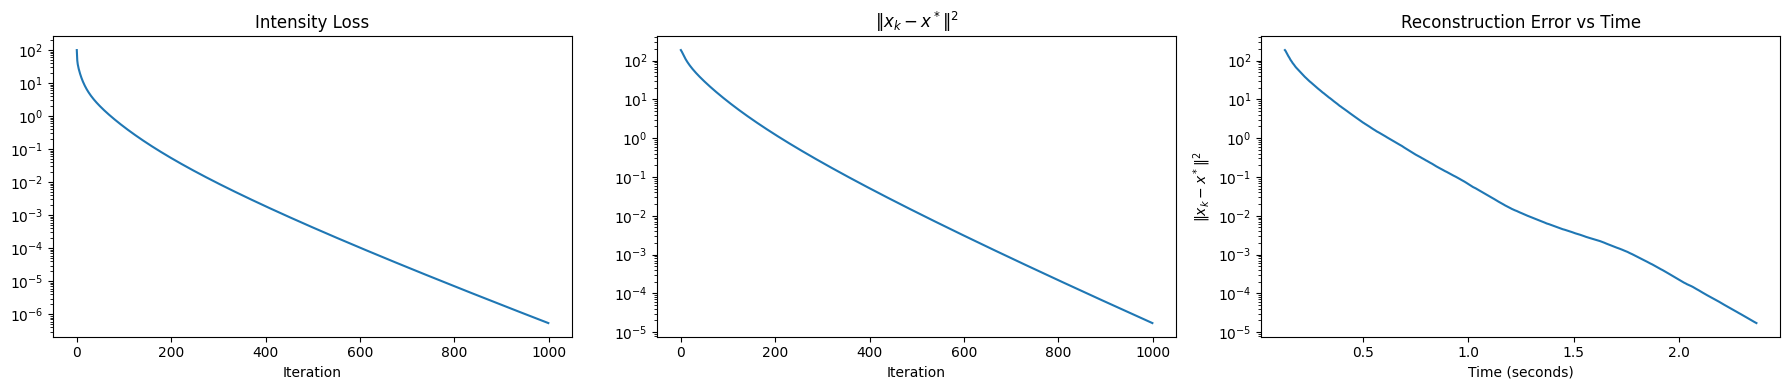

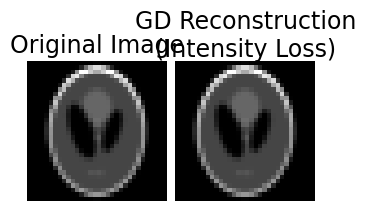

GD Final Loss:          0.000001
GD Final ||x_k-x*||^2:  0.000017


In [6]:
x_init = physics.A_dagger(y, n_iter=300)


if torch.cuda.is_available():
    torch.cuda.synchronize()
start_time = time.perf_counter()

result = gradient_descent_phase_retrieval(
    x_init=x_init,
    y=y,
    physics=physics,
    x_true=x_true,
    step_mode="constant",
    step_size=1e-1,
    loss_type="intensity"
)


if torch.cuda.is_available():
    torch.cuda.synchronize()
end_time = time.perf_counter()

loss_hist = result["loss_hist"]
recon_error_hist = result["recon_error_hist"]
time_hist = result["time_hist"]
x_final = result["x_final"]

total_time = end_time - start_time
avg_time = total_time / num_iter

print_run_summary(loss_hist, total_time, avg_time, method_name="GD")

plot_metrics(loss_hist, recon_error_hist, time_hist, loss_name="Intensity Loss")

x_gd_corrected = correct_global_phase(x_final, x_true)
x_gd_recon = torch.angle(x_gd_corrected) / torch.pi + 0.5
x_true_vis = torch.angle(x_true) / torch.pi + 0.5

plot_reconstruction(
    x_true_vis,
    x_gd_recon,
    title_recon="GD Reconstruction (Intensity Loss)"
)

final_recon_error = print_final_metrics(
    x_gd_corrected,
    x_true,
    loss_hist,
    method_name="GD"
)

GD semi-log convergence estimate
Fit range         : [301, 1000]
slope             : -1.351257e-02
rho = exp(slope)  : 0.986578
R^2               : 0.999338
ratio mean        : 0.986477
ratio median      : 0.986712
ratio std         : 0.000829
model             : e_k ≈ C * rho^k


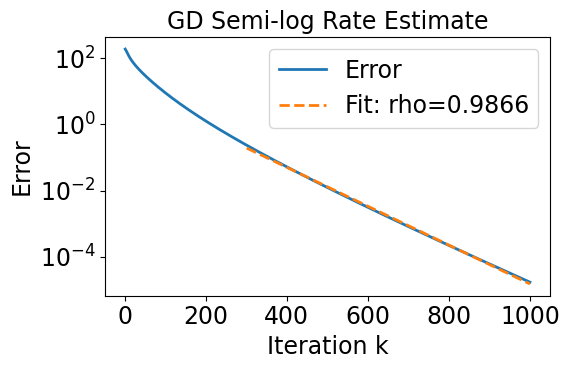

In [7]:
gd_rate = estimate_semilog_rate(
    error_hist=result["recon_error_hist"],
    start_ratio=0.3,
    method_name="GD",
    plot=True
)

[0] loss=40.1297  ||x_k-x*||^2=189.8167  lr=0.100000
[100] loss=0.5934  ||x_k-x*||^2=9.5588  lr=0.100000
[200] loss=0.0521  ||x_k-x*||^2=1.0133  lr=0.100000
[300] loss=0.0065  ||x_k-x*||^2=0.1409  lr=0.100000
[400] loss=0.0010  ||x_k-x*||^2=0.0229  lr=0.100000
[500] loss=0.0002  ||x_k-x*||^2=0.0041  lr=0.100000
[600] loss=0.0000  ||x_k-x*||^2=0.0008  lr=0.100000
[700] loss=0.0000  ||x_k-x*||^2=0.0002  lr=0.100000
[800] loss=0.0000  ||x_k-x*||^2=0.0000  lr=0.100000
[900] loss=0.0000  ||x_k-x*||^2=0.0000  lr=0.100000
GD initial loss: 40.129734
GD final loss:   0.000000
GD total time:   2.3755 sec
GD avg/iter:     0.002375 sec


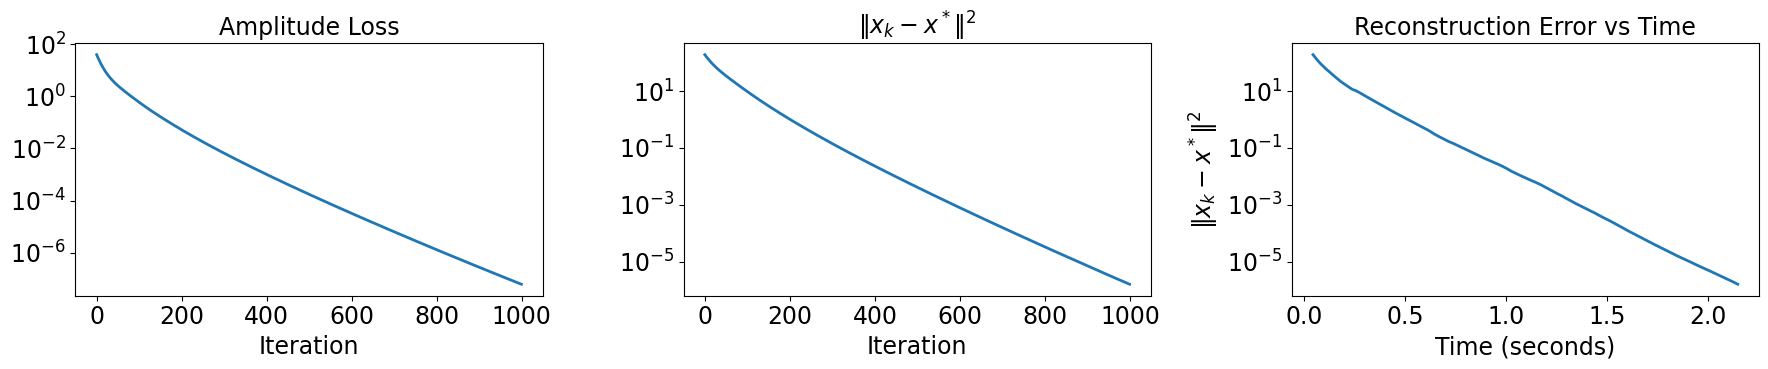

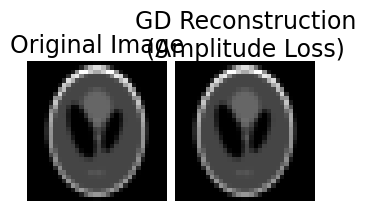

GD Final Loss:          0.000000
GD Final ||x_k-x*||^2:  0.000002


In [8]:
x_init = physics.A_dagger(y, n_iter=300)

result = gradient_descent_phase_retrieval(
    x_init=x_init,
    y=y,
    physics=physics,
    x_true=x_true,
    step_mode="constant",
    step_size=1e-1,
    loss_type="amplitude"
)

loss_hist = result["loss_hist"]
recon_error_hist = result["recon_error_hist"]
time_hist = result["time_hist"]
x_final = result["x_final"]

print_run_summary(loss_hist, total_time, avg_time, method_name="GD")

plot_metrics(loss_hist, recon_error_hist, time_hist, loss_name="Amplitude Loss")

x_gd_corrected = correct_global_phase(x_final, x_true)
x_gd_recon = torch.angle(x_gd_corrected) / torch.pi + 0.5
x_true_vis = torch.angle(x_true) / torch.pi + 0.5

plot_reconstruction(
    x_true_vis,
    x_gd_recon,
    title_recon="GD Reconstruction (Amplitude Loss)"
)

final_recon_error = print_final_metrics(
    x_gd_corrected,
    x_true,
    loss_hist,
    method_name="GD"
)

GD semi-log convergence estimate
Fit range         : [301, 1000]
slope             : -1.618937e-02
rho = exp(slope)  : 0.983941
R^2               : 0.999278
ratio mean        : 0.983847
ratio median      : 0.984072
ratio std         : 0.001030
model             : e_k ≈ C * rho^k


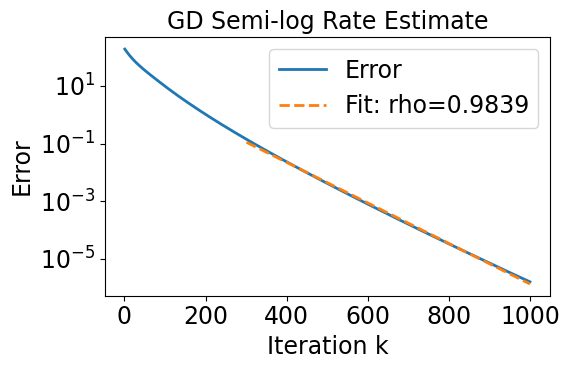

In [9]:
gd_rate = estimate_semilog_rate(
    error_hist=result["recon_error_hist"],
    start_ratio=0.3,
    method_name="GD",
    plot=True
)